In [70]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn kagglehub

In [71]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [72]:
# Download latest version
path = kagglehub.dataset_download("ihormuliar/starbucks-customer-data")

print("Path to dataset files:", path)

# portfolio.csv
portfolio_df = pd.read_csv(path + "/portfolio.csv")

# profile.csv
profile_df = pd.read_csv(path + "/profile.csv")

# transcript.csv
transcript_df = pd.read_csv(path + "/transcript.csv")


transcript_df.shape

100%|██████████| 7.38M/7.38M [00:00<00:00, 81.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ihormuliar/starbucks-customer-data/versions/1


(306534, 5)

In [73]:
portfolio_df.head(), profile_df.head(), transcript_df.head()

(   Unnamed: 0  reward                              channels  difficulty  \
 0           0      10         ['email', 'mobile', 'social']          10   
 1           1      10  ['web', 'email', 'mobile', 'social']          10   
 2           2       0            ['web', 'email', 'mobile']           0   
 3           3       5            ['web', 'email', 'mobile']           5   
 4           4       5                      ['web', 'email']          20   
 
    duration     offer_type                                id  
 0         7           bogo  ae264e3637204a6fb9bb56bc8210ddfd  
 1         5           bogo  4d5c57ea9a6940dd891ad53e9dbe8da0  
 2         4  informational  3f207df678b143eea3cee63160fa8bed  
 3         7           bogo  9b98b8c7a33c4b65b9aebfe6a799e6d9  
 4        10       discount  0b1e1539f2cc45b7b9fa7c272da2e1d7  ,
    Unnamed: 0 gender  age                                id  became_member_on  \
 0           0    NaN  118  68be06ca386d4c31939f3a4f0e3dd783          20170

In [74]:
profile_df = pd.read_csv(path + "/profile.csv")

profile_df.columns = ['index', 'gender', 'age', 'cid', 'memberdate', 'income']

profile_df.drop(['index'], axis=1, inplace=True)

profile_df.info()           #CLEAN UP PROFILE DF


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gender      14825 non-null  object 
 1   age         17000 non-null  int64  
 2   cid         17000 non-null  object 
 3   memberdate  17000 non-null  int64  
 4   income      14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB


In [75]:
portfolio_df = pd.read_csv(path + "/portfolio.csv")


portfolio_df.columns = ['index', 'reward', 'channels', 'difficulty', 'duration', 'offer_type', 'rid']  # Rename columns to merge similarties

portfolio_df.head(10)

,index,reward,channels,difficulty,duration,offer_type,rid
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [76]:
transcript_df = pd.read_csv(path + "/transcript.csv")

transcript_df.columns = ['index', 'cid', 'event', 'rid', 'time'] # Rename columns to merge similarties


# transcript_df.head()

transcript_df['rid'] = transcript_df['rid'].mask(transcript_df['rid'].str[0:10] == "{'offer id", transcript_df['rid'].str[14:-2])       #trim Reward ID
#transcript_df.shape
transcript_df['rid'] = transcript_df['rid'].mask(transcript_df['rid'].str[0:9] == "{'amount'", transcript_df['rid'].str[10:-1])

transcript_df['rid'] = transcript_df['rid'].mask(transcript_df['rid'].str[0:8] == "{'offer_", transcript_df['rid'].str[14:-1])

transcript_df['amount_awarded'] = 0  #Store Award Amount in separate column

transcript_df['amount_awarded'] = transcript_df['amount_awarded'].mask(transcript_df['rid'].str[-3] == ":", transcript_df['rid'].str[-1])

transcript_df['rid'] = transcript_df['rid'].mask((transcript_df['rid'].str[-3] == ":") | (transcript_df['rid'].str[-4] == ":") , transcript_df['rid'].str[0:-14])

transcript_df['rid'] = transcript_df['rid'].mask(transcript_df['rid'].str[-1] == "'" , transcript_df['rid'].str[0:-1])
transcript_df.shape


transcript_df['amount_spent'] = 0                       #store amount spent in separate column
cond = transcript_df['rid'].astype(str).str.len() < 21
transcript_df['amount_spent'] = transcript_df['amount_spent'].mask(cond, transcript_df['rid'].str[:])

transcript_df['amount_spent'].nunique()

transcript_df['rid'] = transcript_df['rid'].mask(cond, 'na')



transcript_df['amount_spent'].nunique()


transcript_df.isna().sum()

#print(transcript_df['rid'].nunique())

# transcript_df['rid'] = transcript_df['rid'].str[14:-2]

#transcript_df['rid'].value_counts()


#transcript_df.head(2)

,0
index,0
cid,0
event,0
rid,0
time,0
amount_awarded,0
amount_spent,0


In [77]:
#merge transcripts to profile so that orders and customers can be correlated

merged = pd.merge(profile_df, transcript_df, on='cid', how='left')

merged.head(30)

merged.shape

merged.isna().sum()



,0
gender,33772
age,0
cid,0
memberdate,0
income,33772
index,0
event,0
rid,0
time,0
amount_awarded,0


In [78]:
#merge the merged copy to the awards portfolio

merged2 = pd.merge(merged, portfolio_df, on='rid', how='left')

merged2.isna().sum()



,0
gender,33772
age,0
cid,0
memberdate,0
income,33772
index_x,0
event,0
rid,0
time,0
amount_awarded,0


In [79]:
#start dropping useless columns

merged2.isna().sum()





merged2.drop(['index_y', 'index_x'], axis = 1, inplace=True)

merged2.isna().sum()




,0
gender,33772
age,0
cid,0
memberdate,0
income,33772
event,0
rid,0
time,0
amount_awarded,0
amount_spent,0


In [80]:
#split data into one section that shows rewards/engagements and one section that shows a transaction

transactionDF = merged2[merged2['rid'] == 'na'] #seperate transactions from merged2

transactionDF.drop(['reward', 'channels', 'difficulty', 'duration', 'offer_type', 'amount_awarded', 'rid'], axis = 1, inplace=True)   #drop data useless for transactions



engagementDF = merged2[merged2['rid'] != 'na'] #seperate offer events from transactions


print(f'Transaction Shape: {transactionDF.shape} Engagement Shape {engagementDF.shape}')


engagementDF.head(30)

Transaction Shape: (138953, 8) Engagement Shape (167581, 15)


/tmp/ipython-input-4288529022.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactionDF.drop(['reward', 'channels', 'difficulty', 'duration', 'offer_type', 'amount_awarded', 'rid'], axis = 1, inplace=True)


,gender,age,cid,memberdate,income,event,rid,time,amount_awarded,amount_spent,reward,channels,difficulty,duration,offer_type
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer received,2906b810c7d4411798c6938adc9daaa5,168,0,0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount
1,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer viewed,2906b810c7d4411798c6938adc9daaa5,216,0,0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount
2,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,336,0,0,5.0,"['web', 'email']",20.0,10.0,discount
3,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer viewed,0b1e1539f2cc45b7b9fa7c272da2e1d7,348,0,0,5.0,"['web', 'email']",20.0,10.0,discount
5,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer received,fafdcd668e3743c1bb461111dcafc2a4,408,0,0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount
6,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer viewed,fafdcd668e3743c1bb461111dcafc2a4,408,0,0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount
9,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer received,2298d6c36e964ae4a3e7e9706d1fb8c2,504,0,0,3.0,"['web', 'email', 'mobile', 'social']",7.0,7.0,discount
10,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer viewed,2298d6c36e964ae4a3e7e9706d1fb8c2,504,0,0,3.0,"['web', 'email', 'mobile', 'social']",7.0,7.0,discount
14,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer completed,fafdcd668e3743c1bb461111dcafc2a4,552,2,0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount
15,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,offer completed,2298d6c36e964ae4a3e7e9706d1fb8c2,552,3,0,3.0,"['web', 'email', 'mobile', 'social']",7.0,7.0,discount


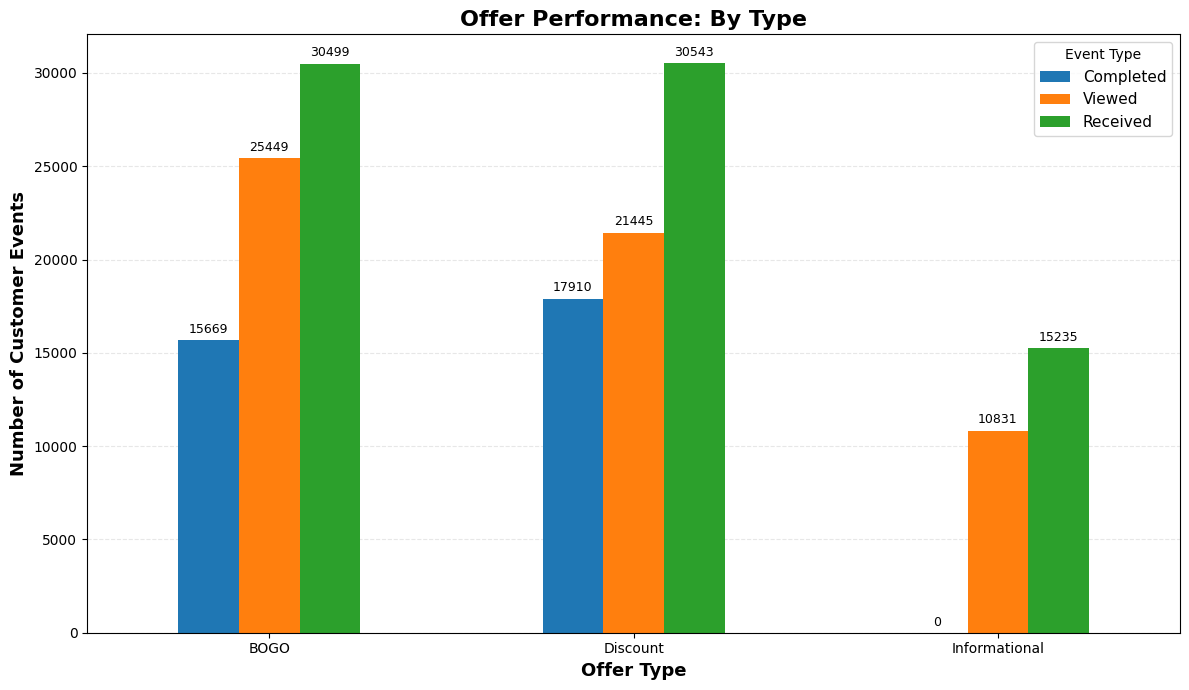

event,offer completed,cxv,offer viewed,vxr,offer received
offer_type,,,,,
bogo,15669.0,0.615702,25449.0,0.834421,30499.0
discount,17910.0,0.835160,21445.0,0.702125,30543.0
informational,NaN,NaN,10831.0,0.710929,15235.0


In [81]:
transactionDF = transactionDF.copy()
transactionDF['amount_spent'] = transactionDF['amount_spent'].astype('float')

engagementDF = engagementDF.copy()
engagementDF['amount_awarded'] = engagementDF['amount_awarded'].astype('float')

# Other options?
#eventNumerical = {"offer received":1, 'offer viewed':2, 'offer completed':3}
#engagementDF['event'] = engagementDF['event'].replace(eventNumerical)

engagementDF[['cid', 'event', 'time']].sort_values(by=['cid', 'time']).head(30)


ratio = engagementDF.groupby(['offer_type', 'event'])['event'].value_counts().unstack()

ratio['vxr'] = ratio['offer viewed'] / ratio['offer received']

ratio['cxv'] = ratio['offer completed'] / ratio['offer viewed']

ratio = ratio[['offer completed', 'cxv', 'offer viewed', 'vxr', 'offer received']]

fig, ax = plt.subplots(figsize=(12, 7))

ratio[['offer completed', 'offer viewed', 'offer received']].plot(kind='bar', ax=ax)

ax.set_title('Offer Performance: By Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Offer Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customer Events', fontsize=13, fontweight='bold')

ax.set_xticklabels(['BOGO', 'Discount', 'Informational'], rotation=0)

ax.legend(['Completed', 'Viewed', 'Received'], loc='upper right', frameon=True, fontsize=11,title='Event Type')

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.tight_layout()
plt.show()
ratio.head()


In [89]:
#gather individual data for engagement and transactions



individualAggData = pd.DataFrame()


avgdiff = engagementDF.groupby('cid')['difficulty'].mean()

avgdurr  = engagementDF.groupby('cid')['duration'].mean()
                                                                    #profile data gathered from the transactions DF listing out the averages for each one of our customers.
avgrew = engagementDF.groupby('cid')['reward'].mean()

eng_count = engagementDF['cid'].value_counts()

avgTimeEngagements = engagementDF.groupby('cid')['time'].mean()

avgAmountAwarded = engagementDF.groupby('cid')['amount_awarded'].mean()

pur_count = transactionDF['cid'].value_counts()

avgTimeSpentPurchase = transactionDF.groupby('cid')['time'].mean()

avgAmountForPurchase = transactionDF.groupby('cid')['amount_spent'].mean()

genderFor   = (profile_df[['cid', 'gender']]
               .drop_duplicates('cid')
               .set_index('cid'))
incomeFor   = (profile_df[['cid', 'income']]
               .drop_duplicates('cid')
               .set_index('cid'))
memberDate  = (profile_df[['cid', 'memberdate']]
               .drop_duplicates('cid')
               .set_index('cid'))

ageFor = (profile_df[['cid', 'age']]
               .drop_duplicates('cid')
               .set_index('cid'))


individualAggData = pd.concat(
    [avgdiff, avgrew, avgdurr, eng_count, pur_count, avgTimeEngagements, avgAmountAwarded, avgTimeSpentPurchase, avgAmountForPurchase, genderFor, incomeFor, memberDate, ageFor],
    axis=1
)


individualAggData.head()

individualAggData.columns = ['avg difficulty', 'avg reward', 'avg duration', 'engagement_count', 'purchase_count', 'avg time for engagements', 'avg amount awarded', 'avg time purchase', 'avg amount for purchase', 'gender', 'income', 'memberdate', 'age']

individualAggData.head()




,avg difficulty,avg reward,avg duration,engagement_count,purchase_count,avg time for engagements,avg amount awarded,avg time purchase,avg amount for purchase,gender,income,memberdate,age
cid,,,,,,,,,,,,,
0009655768c64bdeb2e877511632db8f,5.416667,2.083333,6.083333,12.0,8.0,422.500000,0.750000,543.00,15.950000,M,72000.0,20170421,33
00116118485d4dfda04fdbaba9a87b5c,5.000000,5.000000,5.000000,4.0,3.0,397.500000,0.000000,408.00,1.363333,NaN,NaN,20180425,118
0011e0d4e6b944f998e987f904e8c1e5,7.384615,3.000000,6.615385,13.0,5.0,331.846154,1.000000,451.20,15.892000,O,57000.0,20180109,40
0020c2b971eb4e9188eac86d93036a77,8.181818,4.545455,7.090909,11.0,8.0,326.181818,0.363636,348.75,24.607500,F,90000.0,20160304,59
0020ccbbb6d84e358d3414a3ff76cffd,4.636364,3.545455,5.727273,11.0,12.0,374.727273,1.181818,375.00,12.837500,F,60000.0,20161111,24


/tmp/ipython-input-4162395561.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  engagePivot = heatMapdf.pivot_table(
/tmp/ipython-input-4162395561.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  amountPivot = heatMapdf.pivot_table(


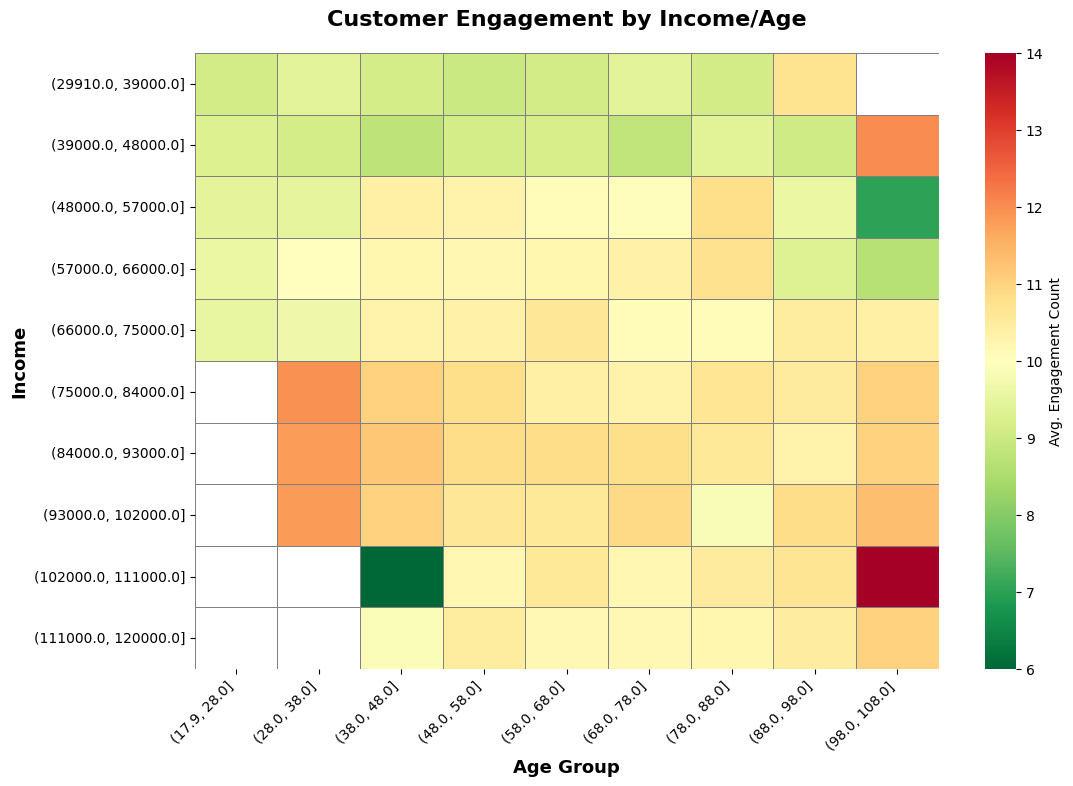

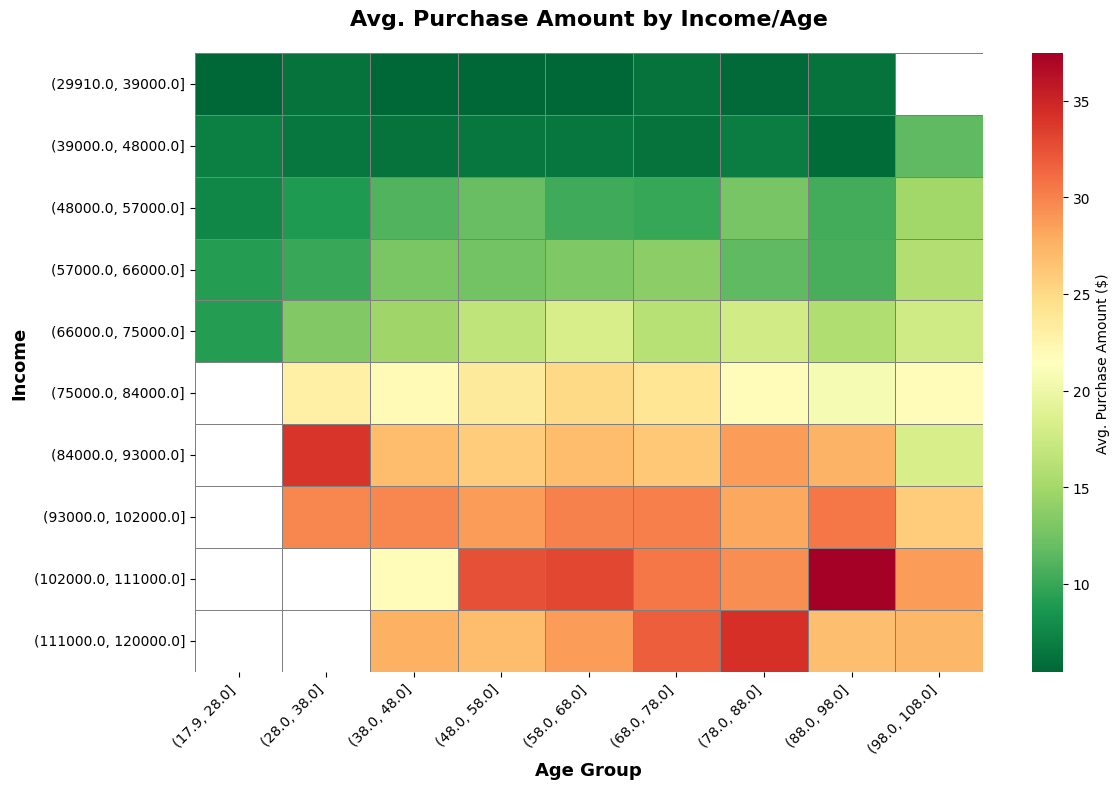

In [83]:
#create a pivot table for a heat map to display demographic data

heatMapdf = individualAggData.copy()
heatMapdf['age'] = pd.cut(individualAggData['age'], bins=10)
heatMapdf['income'] = pd.cut(individualAggData['income'], bins=10)
heatMapdf['memberdate'] = pd.cut(individualAggData['memberdate'], bins=10)
heatMapdf['avg reward'] = pd.cut(individualAggData['avg reward'], bins=10)
heatMapdf['avg difficulty'] = pd.cut(individualAggData['avg difficulty'], bins=10)

#engagements considered from income and age
engagePivot = heatMapdf.pivot_table(
    index='income',
    columns='age',
    values='engagement_count',
    aggfunc='mean'

)

#purchase amount considered from income and age
amountPivot = heatMapdf.pivot_table(
    index='income',
    columns='age',
    values='avg amount for purchase',
    aggfunc='mean'
)

# Engagements Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(engagePivot, cmap='RdYlGn_r', fmt='.1f', cbar_kws={'label': 'Avg. Engagement Count'}, linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('Customer Engagement by Income/Age', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Income', fontsize=13, fontweight='bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Purchase Amount Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(amountPivot, cmap='RdYlGn_r', fmt='.1f', cbar_kws={'label': 'Avg. Purchase Amount ($)'}, linewidths=0.5, linecolor='gray',ax=ax)

ax.set_title('Avg. Purchase Amount by Income/Age', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Income', fontsize=13, fontweight='bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)


plt.tight_layout()
plt.show()


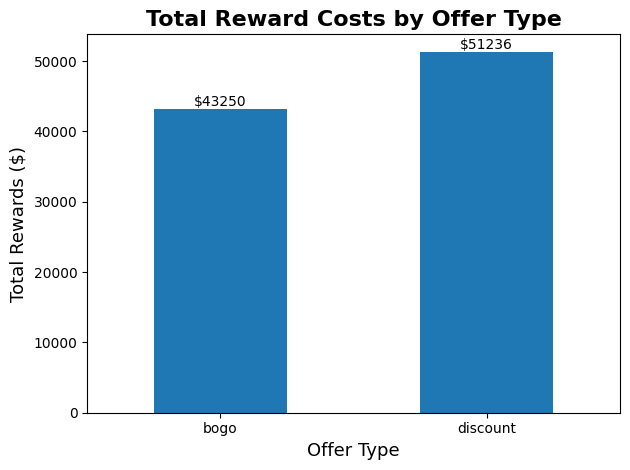

In [84]:
# create bar chart showing the effectivness of various offers by amount awarded
# Total Rewards Cost by Offer Type
engagementDF[engagementDF['offer_type'] != 'informational'].groupby('offer_type')['amount_awarded'].sum().plot(kind='bar')


plt.title('Total Reward Costs by Offer Type', fontsize=16, fontweight='bold')
plt.xlabel('Offer Type', fontsize=13)
plt.ylabel('Total Rewards ($)', fontsize=13)
plt.xticks(rotation=0)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f')

plt.tight_layout()
plt.show()

,avg difficulty,avg reward,avg duration,engagement_count,purchase_count,avg time for engagements,avg amount awarded,avg time purchase,avg amount for purchase,gender,income,memberdate,age
cid,,,,,,,,,,,,,
0009655768c64bdeb2e877511632db8f,5.416667,2.083333,6.083333,12.0,8.0,422.500000,0.750000,543.000000,15.950000,M,72000.0,20170421,33
00116118485d4dfda04fdbaba9a87b5c,5.000000,5.000000,5.000000,4.0,3.0,397.500000,0.000000,408.000000,1.363333,NaN,NaN,20180425,118
0011e0d4e6b944f998e987f904e8c1e5,7.384615,3.000000,6.615385,13.0,5.0,331.846154,1.000000,451.200000,15.892000,O,57000.0,20180109,40
0020c2b971eb4e9188eac86d93036a77,8.181818,4.545455,7.090909,11.0,8.0,326.181818,0.363636,348.750000,24.607500,F,90000.0,20160304,59
0020ccbbb6d84e358d3414a3ff76cffd,4.636364,3.545455,5.727273,11.0,12.0,374.727273,1.181818,375.000000,12.837500,F,60000.0,20161111,24
003d66b6608740288d6cc97a6903f4f0,8.333333,1.833333,7.833333,12.0,18.0,344.000000,0.750000,421.666667,2.685556,F,73000.0,20170621,26
00426fe3ffde4c6b9cb9ad6d077a13ea,8.750000,1.875000,7.500000,8.0,17.0,246.000000,0.250000,266.823529,4.030000,F,65000.0,20160809,19
004b041fbfe44859945daa2c7f79ee64,6.428571,3.000000,7.000000,7.0,6.0,511.714286,1.000000,391.000000,23.060000,F,74000.0,20180508,55
004c5799adbf42868b9cff0396190900,7.857143,4.428571,7.428571,14.0,12.0,418.714286,1.000000,450.500000,28.948333,M,99000.0,20160331,54


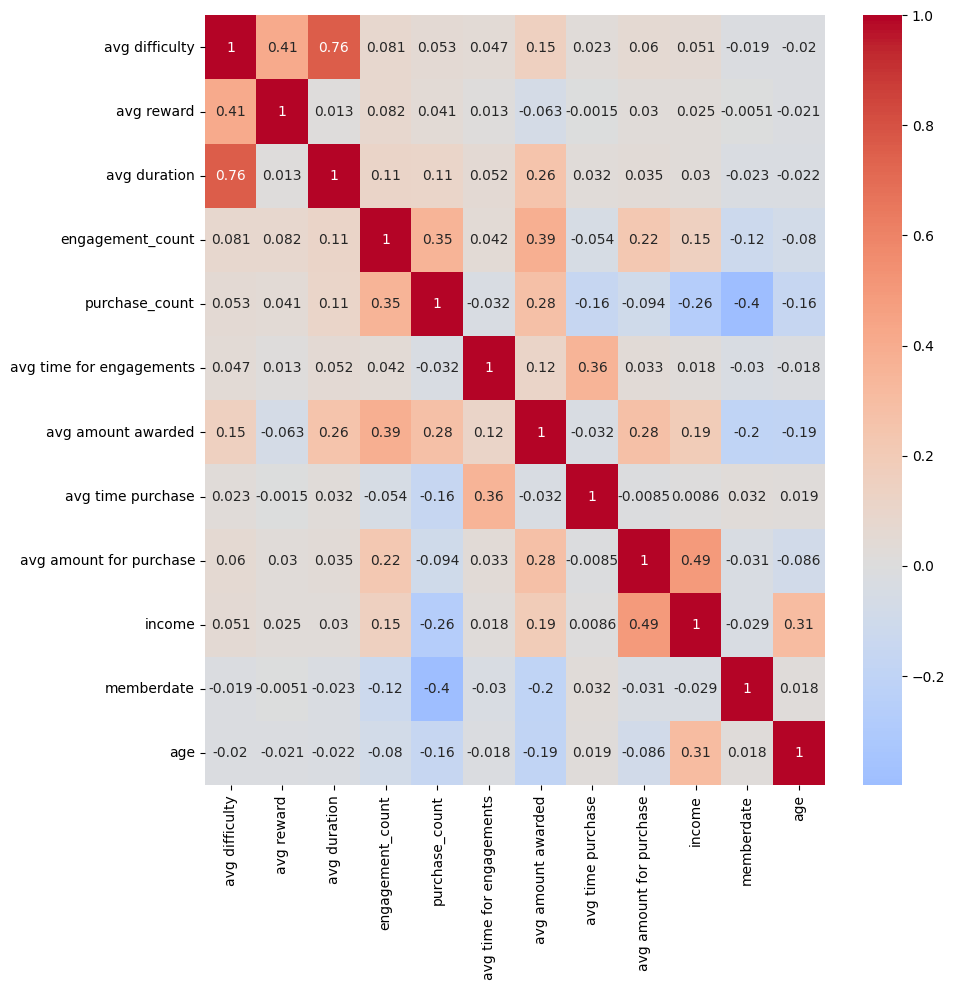

In [85]:


corr = individualAggData.corr(numeric_only=True)  #correlation between features

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)





individualAggData.head(30)

Offer measured by difference in offered viewed and complete.
Offer measured by

slope: [9.71303138]
intercept: [7.69949837]
r2: 0.144207400124446
mse: 102.17415862134598


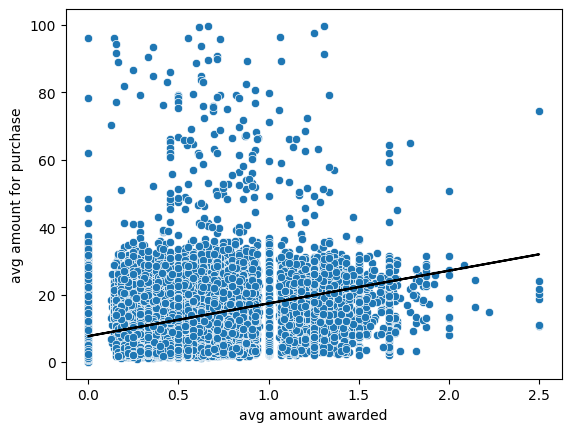

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lm = LinearRegression()






avg = individualAggData.copy()



mask1 = (avg['avg amount for purchase'] < 100) #mask to trim outlier

avg = avg.loc[mask1]

medianAA = avg['avg amount awarded'].median()
medianAP = avg['avg amount for purchase'].median()    #median gather to fill NAs


X = avg['avg amount awarded'].fillna(medianAA).values.reshape(-1, 1)
y = avg['avg amount for purchase'].fillna(medianAP).values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)  #train test split


lm.fit(X_train, y_train)    #train and prediction

y_pred = lm.predict(X_test)



sns.scatterplot(data=avg, y='avg amount for purchase', x='avg amount awarded')
plt.plot(X_test, y_pred, color='black')

print("slope:", lm.coef_[0])
print("intercept:", lm.intercept_)
print("r2:", r2_score(y_test, y_pred))
print("mse:", mean_squared_error(y_test, y_pred))



/tmp/ipython-input-474350863.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  engagementDF['difficulty'].fillna(medianDiff, inplace=True)
/tmp/ipython-input-474350863.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Accuracy: 66.15%

Classification Report:
              precision    recall  f1-score   support

 Incompletes       0.92      0.66      0.77     42285
   Completes       0.27      0.69      0.39      7990

    accuracy                           0.66     50275
   macro avg       0.60      0.67      0.58     50275
weighted avg       0.82      0.66      0.71     50275



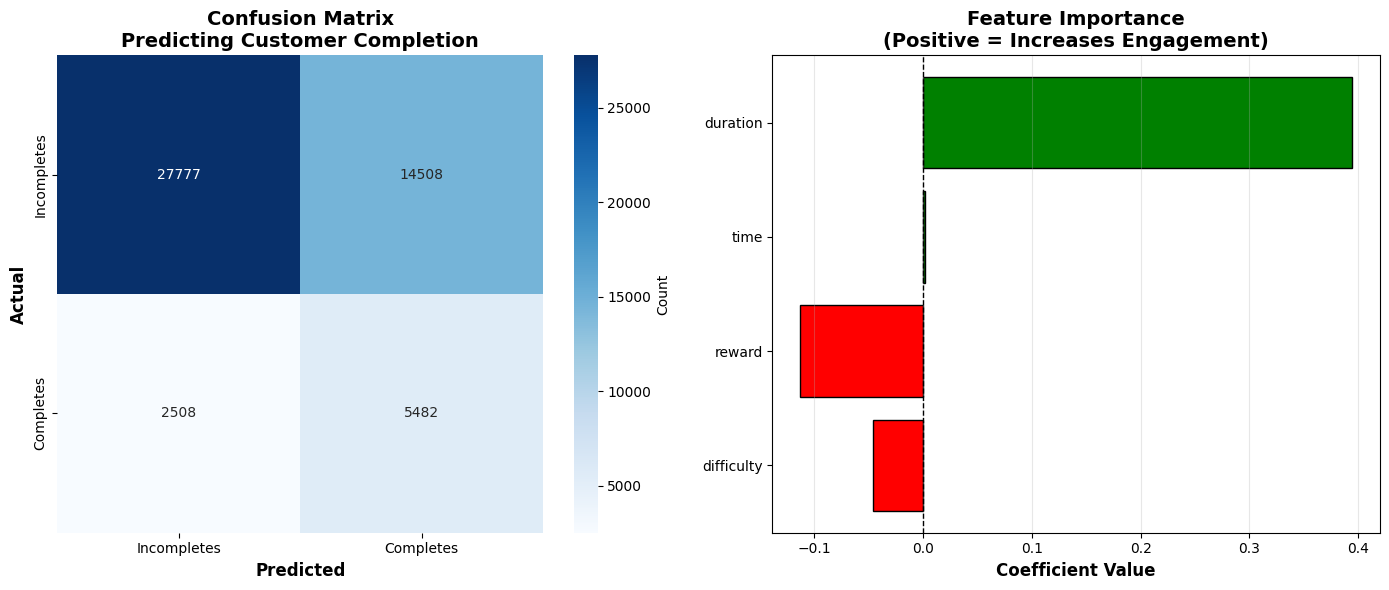

Model Accuracy: 66.2%


,count
amount_awarded,
False,141021
True,26560


In [87]:
# Predict offer completion instead of purchase amount - Will they complete offer? Yes or No

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Create target variable
engagementDF['completes_offers'] = (engagementDF['amount_awarded'] > 0)

medianDiff, medianReward, medianTime, medianDur = engagementDF['difficulty'].median(), engagementDF['reward'].median(), engagementDF['time'].median(), engagementDF['duration'].median()   # median was gathered to fill the NA spots

engagementDF['difficulty'].fillna(medianDiff, inplace=True)   #median fill was used here to fill the gaps
engagementDF['reward'].fillna(medianReward, inplace=True)
engagementDF['time'].fillna(medianTime, inplace=True)
engagementDF['duration'].fillna(medianDur, inplace=True)




# Features
X = engagementDF[['difficulty', 'reward', 'time', 'duration' ]]     #the independent variables
y = engagementDF['completes_offers']  #the dependent variable

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
log_model = LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42)

log_model.fit(X_train, y_train)     #train and predict with model.
y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)     #examine scores
print(f"Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Incompletes', 'Completes']))

# Create confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Incompletes', 'Completes'],yticklabels=['Incompletes', 'Completes'], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix\nPredicting Customer Completion', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')

# Feature Importance
feature_names = ['difficulty', 'reward', 'time', 'duration']
importances = log_model.coef_[0]
colors = ['green' if x > 0 else 'red' for x in importances]

axes[1].barh(feature_names, importances, color=colors, edgecolor='black')
axes[1].set_title('Feature Importance\n(Positive = Increases Engagement)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Model Accuracy: {accuracy:.1%}")



